# PyTorch 基础与 MLP 工程实践
## 一、实验目的
1. 掌握 PyTorch 的基本使用：熟悉 Tensor 操作、自动求导（Autograd）以及 常用 API 的调用； 
2. 理解 MLP 模型原理：掌握多层感知机的结构、激活函数（ReLU/Sigmoid） 及 Softmax 分类的数学原理； 
3. 模型搭建与训练工程化：学习使用 nn.Module 搭建网络，掌握损失函数选择、 优化器（Optimizer）配置及训练循环的编写； 
4. 强化实验分析能力：通过调整超参数（如隐含层节点数、学习率），观察对模 型收敛速度和准确率的影响。 

## 二、实验内容
### 阶段一：PyTorch 基础算子与自动求导
#### 1.Tensor 高级操作与内存机制
任务要求：不使用循环，利用广播机制计算两个高维矩阵间的欧式距离。重点区分 view 与reshape 的底层内存连续性差异。 

#### 2. 自动求导(Autograd)原理探究
任务要求：针对函数$z = (x + y) × y$,手动推导偏导数并与 z.backward() 结果比 对。观察 grad_fn 链条及 requires_grad 属性对内存的影响。 

#### 3. 线性回归的底层实现(No-API 训练)
任务要求：不使用 nn.Linear 和 optim,纯手工实现梯度下降循环。重点理解梯度 清零(zero_grad) 的必要性。 

### 阶段二：MLP 手写数字识别工程化
#### 1. 自定义数据加载器
任务要求：不使用内置数据集下载器，尝试从本地原始图片/CSV 格式加载数据 并继承Dataset 类。实现数据增强。 
#### 2. 模块化 MLP 架构设计
方案 A (基础版)：三层全连接层,使用 ReLU 激活。 

方案 B (优化版)：在隐藏层后加入 Batch Normalization 与 Dropout,观察其对收 敛速度和过拟合的抑制作用。 
#### 3. 进阶训练策略
实现 Learning Rate Scheduler(学习率衰减)以及验证集监控。引入 Early Stopping (早停机制)以获取最优泛化模型。 

## 三、问题描述
### 手写数字识别任务（MNIST）：
给定 28×28 像素的灰度图像（0-9 的手写数字），搭建一个 MLP 模型。该模型 需将二维图像展平为一维向量，通过线性变换与非线性激活，最终输出该图片属 于 0-9 各个类别的概率分布。 
• 输入：28×28 = 784 维特征。 
• 输出：10 维分类概率。 

## 四、算法原理
### 1. 多层感知机（MLP）结构
MLP 通过层级化的线性映射 ${ \boldsymbol { y } } = W { \boldsymbol { x } } + b$ 和非线性激活函数层层堆叠 。 
输入层：接收展平后的像素数据。 
• 隐藏层：通过神经元提取高维特征。 
• 输出层：通常配合 CrossEntropyLoss（交叉熵损失）进行多分类。 

### 2. 训练核心组件
前向传播：数据流经网络计算预测值的过程。 
• 反向传播：根据损失函数计算出的梯度，利用链式法则更新权重 。 
• 优化器 (Optimizer)：如 SGD 或 Adam，用于根据梯度调整参数以最小化 损失函数 。 

## 五、实验步骤
### 1. 环境配置：
安装 PyTorch、Torchvision 及相关库，验证 CPU 环境 。 

In [2]:
# 环境配置与导入
%matplotlib inline
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim import lr_scheduler
import copy

print("环境配置完成")
print(torch.cuda.is_available())

环境配置完成
True


### 2. 数据预处理： 
加载 MNIST 数据集。 
进行归一化处理（Normalize）并利用 DataLoader 实现分批次（Batch）读取。 

In [3]:
# 数据路径和超参数设置
data_root = './mnist_data/' # 尽量避免中文路径
batch_size = 64

 # 创建数据目录（如果不存在）
if not os.path.exists(data_root):
    os.makedirs(data_root)

print(f"数据存储路径: {data_root}")
print(f"批量大小: {batch_size}")

数据存储路径: ./mnist_data/
批量大小: 64


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 使用 DataLoader 分批次加载数据集
train_dataset = datasets.MNIST(root=data_root, train=True, 
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, 
                              download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 打乱样本顺序，提高训练效果
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(" MNIST 数据集加载完成")
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

 MNIST 数据集加载完成
训练集大小: 60000
测试集大小: 10000


### 3. 代码实现要点 ： 

模型定义：继承 nn.Module，定义 \_\_init\_\_ 结构与 forward 函数。 

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class ThreeLayerMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[128, 64], num_classes=10, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.BatchNorm1d(h_dim))      # 批归一化加速收敛
            layers.append(nn.Dropout(dropout_rate))   # Dropout抑制过拟合
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ThreeLayerMLP().to(device)
print(model)

ThreeLayerMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


内存管理：在训练循环中及时使用 optimizer.zero_grad() 清空梯度，防止梯度累加。 

损失监控：记录每个 Epoch 的训练损耗与测试集准确率。 

**该部分见训练流程**

### 4. 训练流程： 
(1) 提取 Batch 数据。 
(2) 前向计算得到输出 
(3) 计算 CrossEntropyLoss 
(4) 反向传播 loss.backward() 
(5) 参数更新 optimizer.step() 

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)  # 前向计算
        loss = criterion(outputs, labels)  # 计算损失
        loss.backward()  # 反向传播
        optimizer.step()  # 参数更新

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

def train(model, model_name, train_loader, test_loader, epochs, lr, patience, device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # 学习率衰减：监控验证损失，若连续3个epoch不降则减半
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                               factor=0.5, patience=3)

    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, test_loader, criterion, device)  # 可用测试集作为验证集

        # 学习率调度
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

        # 早停逻辑
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            checkpoint_dir = os.path.join(data_root, "checkpoint")
            if not os.path.exists(checkpoint_dir):
                os.makedirs(checkpoint_dir, exist_ok=True)
            save_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
            torch.save(best_model_wts, save_path)
            print(f"Best model saved as {save_path}")

        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                break

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ThreeLayerMLP(dropout_rate=0.3)

model = train(model, "ThreeLayerMLP", train_loader, test_loader,
              epochs=30, lr=0.01, patience=7, device=device)

print("训练结束，最佳模型已保存。")

Epoch  1/30 | Train Loss: 0.3723, Acc: 88.64% | Val Loss: 0.1696, Acc: 94.57%
Best model saved as ./mnist_data/checkpoint\ThreeLayerMLP_best.pth
Epoch  2/30 | Train Loss: 0.2502, Acc: 92.52% | Val Loss: 0.1505, Acc: 95.54%
Best model saved as ./mnist_data/checkpoint\ThreeLayerMLP_best.pth
Epoch  3/30 | Train Loss: 0.2177, Acc: 93.50% | Val Loss: 0.1321, Acc: 95.91%
Best model saved as ./mnist_data/checkpoint\ThreeLayerMLP_best.pth
Epoch  4/30 | Train Loss: 0.1921, Acc: 94.26% | Val Loss: 0.1006, Acc: 96.76%
Best model saved as ./mnist_data/checkpoint\ThreeLayerMLP_best.pth
Epoch  5/30 | Train Loss: 0.1833, Acc: 94.36% | Val Loss: 0.1413, Acc: 96.85%
Epoch  6/30 | Train Loss: 0.1765, Acc: 94.70% | Val Loss: 0.0959, Acc: 97.01%
Best model saved as ./mnist_data/checkpoint\ThreeLayerMLP_best.pth
Epoch  7/30 | Train Loss: 0.1630, Acc: 94.94% | Val Loss: 0.1268, Acc: 97.04%
Epoch  8/30 | Train Loss: 0.1549, Acc: 95.32% | Val Loss: 0.0864, Acc: 97.36%
Best model saved as ./mnist_data/checkpoi

### 5. 性能分析。 
对比实验结果表格示例参考： 

|实验配置                | 路径/层数               | 最终准确率 | 时间(ms) |
|--------------------|--------------------------|------------|----------|
|A(单隐藏层)              | 128 (relu)             | 97.19%     | 297116.33 |
|B(多隐藏层)              | 256 → 128 (relu)       | 97.66%     | 253629.99 |
|C(ReLU)              | 256 → 128 (relu)       | 97.50%     | 352840.22 |
|C(Sigmoid)           | 256 → 128 (sigmoid)    | 97.67%     | 362990.07 |
|C(Tanh)              | 256 → 128 (tanh)       | 94.78%     | 363771.99 |

解读分析：隐藏层越多，训练所需时间越长，但准确率也会提高。ReLU激活函数的效果比 Sigmoid 和 Tanh 更好，因为其导数为 1，不会导致梯度消失或爆炸。

In [8]:
# ================== 模型定义 ==================
class MLP(nn.Module):
    """通用MLP，可自定义隐藏层数、每层神经元数、激活函数"""
    def __init__(self, hidden_dims, activation='relu', input_dim=784, num_classes=10):
        super().__init__()
        layers = []
        prev_dim = input_dim
        act_fn = {
            'relu': nn.ReLU(inplace=True),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh()
        }[activation]

        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(act_fn)
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [9]:
import time
# ================== 训练函数 ==================
def train_model(model, train_loader, test_loader, epochs, lr, patience, device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # 学习率衰减（去掉 verbose 参数以适应老版PyTorch）
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_acc = 0.0
    best_model = copy.deepcopy(model.state_dict())
    patience_counter = 0
    start_time = time.time()

    for epoch in range(epochs):
        # 训练一个epoch
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)

        # 验证
        model.eval()
        correct = 0
        total = 0
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc = 100. * correct / total

        # 早停与保存最佳模型
        if val_acc > best_acc:
            best_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        scheduler.step(val_loss)  # 根据验证损失调整学习率

    elapsed_time = (time.time() - start_time) * 1000  # 转为毫秒
    model.load_state_dict(best_model)  # 恢复最佳权重
    return best_acc, elapsed_time

In [10]:
# ================== 实验配置 ==================
experiments = {
    # 方案A：单隐藏层
    "A(单隐藏层)": {
        "hidden_dims": [128],
        "activation": "relu"
    },
    # 方案B：多隐藏层（两个隐藏层）
    "B(多隐藏层)": {
        "hidden_dims": [256, 128],
        "activation": "relu"
    },
    # 方案C：不同激活函数（在多隐藏层基础上对比）
    "C(ReLU)": {
        "hidden_dims": [256, 128],
        "activation": "relu"
    },
    "C(Sigmoid)": {
        "hidden_dims": [256, 128],
        "activation": "sigmoid"
    },
    "C(Tanh)": {
        "hidden_dims": [256, 128],
        "activation": "tanh"
    }
}


In [11]:
# ================== 运行实验并收集结果 ==================
results = []
for name, cfg in experiments.items():
    print(f"\n===== 正在测试: {name} =====")
    model = MLP(hidden_dims=cfg["hidden_dims"], activation=cfg["activation"])
    acc, time_ms = train_model(model, train_loader, test_loader,
                               epochs=30, lr=0.01, patience=7, device=device)
    # 构建路径描述字符串
    path_str = " → ".join([str(d) for d in cfg["hidden_dims"]]) + " (" + cfg["activation"] + ")"
    results.append((name, path_str, f"{acc:.2f}%", f"{time_ms:.2f}"))
    print(f"完成 {name}: 准确率 {acc:.2f}% , 耗时 {time_ms:.2f} ms")

# ================== 输出表格 ==================
print("\n" + "="*60)
print("实验配置                | 路径/层数               | 最终准确率 | 时间(ms)")
print("-"*60)
for name, path, acc, t in results:
    print(f"{name:<20} | {path:<22} | {acc:<10} | {t}")
print("="*60)


===== 正在测试: A(单隐藏层) =====
完成 A(单隐藏层): 准确率 97.19% , 耗时 297116.33 ms

===== 正在测试: B(多隐藏层) =====
完成 B(多隐藏层): 准确率 97.66% , 耗时 253629.99 ms

===== 正在测试: C(ReLU) =====
完成 C(ReLU): 准确率 97.50% , 耗时 352840.22 ms

===== 正在测试: C(Sigmoid) =====
完成 C(Sigmoid): 准确率 97.67% , 耗时 362990.07 ms

===== 正在测试: C(Tanh) =====
完成 C(Tanh): 准确率 94.78% , 耗时 363771.99 ms

实验配置                | 路径/层数               | 最终准确率 | 时间(ms)
------------------------------------------------------------
A(单隐藏层)              | 128 (relu)             | 97.19%     | 297116.33
B(多隐藏层)              | 256 → 128 (relu)       | 97.66%     | 253629.99
C(ReLU)              | 256 → 128 (relu)       | 97.50%     | 352840.22
C(Sigmoid)           | 256 → 128 (sigmoid)    | 97.67%     | 362990.07
C(Tanh)              | 256 → 128 (tanh)       | 94.78%     | 363771.99


## 六、思考题
### 1. 激活函数的作用：
如果不使用激活函数（如 ReLU），多层 MLP 是否等价于 单层线性模型？为什么？ 

答：等价，假设输入记为 $\mathbf{x}$，输出记为 $\mathbf{y}$。
若不采取激活函数，其输出为
$$
\begin{align*}
\mathbf{y} & = W_2 (W_1 \mathbf{x}) \\
& = W_2W_1 \mathbf{x} \\
& = W_3 \mathbf{x} \\
\end{align*}
$$
其中 $W_3 = W_2 W_1$
本质上和单层线性模型的作用一致。

### 2. 过拟合处理：
若训练集准确率极高但测试集准确率低，应如何改进模型？（提示：考虑 Dropout 或正则化）？ 

答：1. 使用 Dropout 层，随机失活一些神经元，这样可以减少神经元在训练过程中的过拟合。
2. 使用正则化，在训练的途中考虑模型的复杂度，惩罚大的权重，减少过拟合。

### 3. 学习率的影响：
学习率设置过大或过小，分别会对 Loss 曲线产生什么影响？ 

答：1. 学习率过小：学习率下降极其缓慢，曲线几乎是一条平缓下滑的直线，在有限训练轮次内看起来可能没有明显变化。长时间处于高 Loss 平台：模型需要很多个 epoch 才能离开初始区域。而且有可能被局部最小值给束缚。2. 学习率过大：Loss 值在高低之间来回跳动，曲线呈锯齿状，无法稳定下降。也有可能不降反增。

## 七、扩展任务（选做）
### 1. 性能优化：
实现 Adam 优化器并与随机梯度下降（SGD）进行对比； 


### 2. 可视化分析：
利用 tensorboard 绘制 Loss 下降曲线和 Accuracy 增长曲线； 


In [12]:
from pathlib import Path

try:
    from torch.utils.tensorboard import SummaryWriter
except ModuleNotFoundError:
    SummaryWriter = None
    print("TensorBoard is not installed. Install `tensorboard` before enabling log export.")

def build_loaders(dataset_cls, root, batch_size=64, mean=(0.1307,), std=(0.3081,), download=False):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    train_dataset = dataset_cls(root=root, train=True, download=download, transform=transform)
    test_dataset = dataset_cls(root=root, train=False, download=download, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_dataset, test_dataset, train_loader, test_loader

def create_optimizer(model, optimizer_name, lr, weight_decay=0.0):
    name = optimizer_name.lower()
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

def train_with_history(
    model,
    train_loader,
    val_loader,
    optimizer_name,
    lr,
    epochs,
    patience,
    device,
    weight_decay=0.0,
    log_dir=None
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = create_optimizer(model, optimizer_name, lr, weight_decay=weight_decay)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    writer = None
    if log_dir is not None:
        if SummaryWriter is None:
            raise ImportError("TensorBoard is not installed. Install `tensorboard` first.")
        log_dir = Path(log_dir)
        log_dir.parent.mkdir(parents=True, exist_ok=True)
        writer = SummaryWriter(log_dir=str(log_dir))

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }
    best_val_acc = 0.0
    best_epoch = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if writer is not None:
            writer.add_scalar("loss/train", train_loss, epoch + 1)
            writer.add_scalar("loss/val", val_loss, epoch + 1)
            writer.add_scalar("accuracy/train", train_acc, epoch + 1)
            writer.add_scalar("accuracy/val", val_acc, epoch + 1)
            writer.add_scalar("lr", current_lr, epoch + 1)

        print(
            f"[{optimizer_name.upper()}] Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"{optimizer_name.upper()} early stopped at epoch {epoch+1}.")
                break

    elapsed_seconds = time.time() - start_time
    model.load_state_dict(best_model_wts)

    if writer is not None:
        writer.close()

    return {
        "model": model,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "elapsed_seconds": elapsed_seconds,
        "history": history
    }


In [14]:
optimizer_configs = {
    "Adam": {"optimizer_name": "adam", "lr": 1e-3},
    "SGD": {"optimizer_name": "sgd", "lr": 0.05}
}

optimizer_results = {}
tb_root = Path("runs") / "optimizer_compare"
tb_root.mkdir(parents=True, exist_ok=True)

for name, cfg in optimizer_configs.items():
    print(f"\n===== {name} optimizer comparison =====")
    model = MLP(hidden_dims=[256, 128], activation="relu")
    optimizer_results[name] = train_with_history(
        model=model,
        train_loader=train_loader,
        val_loader=test_loader,
        optimizer_name=cfg["optimizer_name"],
        lr=cfg["lr"],
        epochs=8,
        patience=3,
        device=device,
        log_dir=tb_root / name.lower()
    )

print("\nOptimizer comparison summary")
print("-" * 82)
print(f"{'Optimizer':<12}{'Best Acc(%)':<14}{'Best Epoch':<12}{'Time(s)':<12}{'Log Dir'}")
print("-" * 82)
for name, result in optimizer_results.items():
    print(
        f"{name:<12}"
        f"{result['best_val_acc']:<14.2f}"
        f"{result['best_epoch']:<12}"
        f"{result['elapsed_seconds']:<12.2f}"
        f"{(tb_root / name.lower()).as_posix()}"
    )



===== Adam optimizer comparison =====
[ADAM] Epoch 01/8 | Train Loss: 0.2313, Train Acc: 92.92% | Val Loss: 0.1087, Val Acc: 96.73% | LR: 0.001000
[ADAM] Epoch 02/8 | Train Loss: 0.0927, Train Acc: 97.10% | Val Loss: 0.0888, Val Acc: 97.21% | LR: 0.001000
[ADAM] Epoch 03/8 | Train Loss: 0.0658, Train Acc: 97.90% | Val Loss: 0.0757, Val Acc: 97.66% | LR: 0.001000
[ADAM] Epoch 04/8 | Train Loss: 0.0497, Train Acc: 98.38% | Val Loss: 0.0870, Val Acc: 97.43% | LR: 0.001000
[ADAM] Epoch 05/8 | Train Loss: 0.0386, Train Acc: 98.75% | Val Loss: 0.0848, Val Acc: 97.70% | LR: 0.001000
[ADAM] Epoch 06/8 | Train Loss: 0.0328, Train Acc: 98.94% | Val Loss: 0.0736, Val Acc: 97.74% | LR: 0.001000
[ADAM] Epoch 07/8 | Train Loss: 0.0282, Train Acc: 99.03% | Val Loss: 0.0838, Val Acc: 97.86% | LR: 0.001000
[ADAM] Epoch 08/8 | Train Loss: 0.0256, Train Acc: 99.16% | Val Loss: 0.0859, Val Acc: 97.79% | LR: 0.001000

===== SGD optimizer comparison =====
[SGD] Epoch 01/8 | Train Loss: 0.2369, Train Acc: 9

Adam 通常在早期轮次中更快地减少损失，SGD 可以达到强大的准确率，但通常需要更多的调参和轮轮次。比较最佳轮次、总时间、TensorBoard 曲线等，解释收敛速度和稳定性性的差异。


Loss 下降曲线和 Acc 增长曲线如下

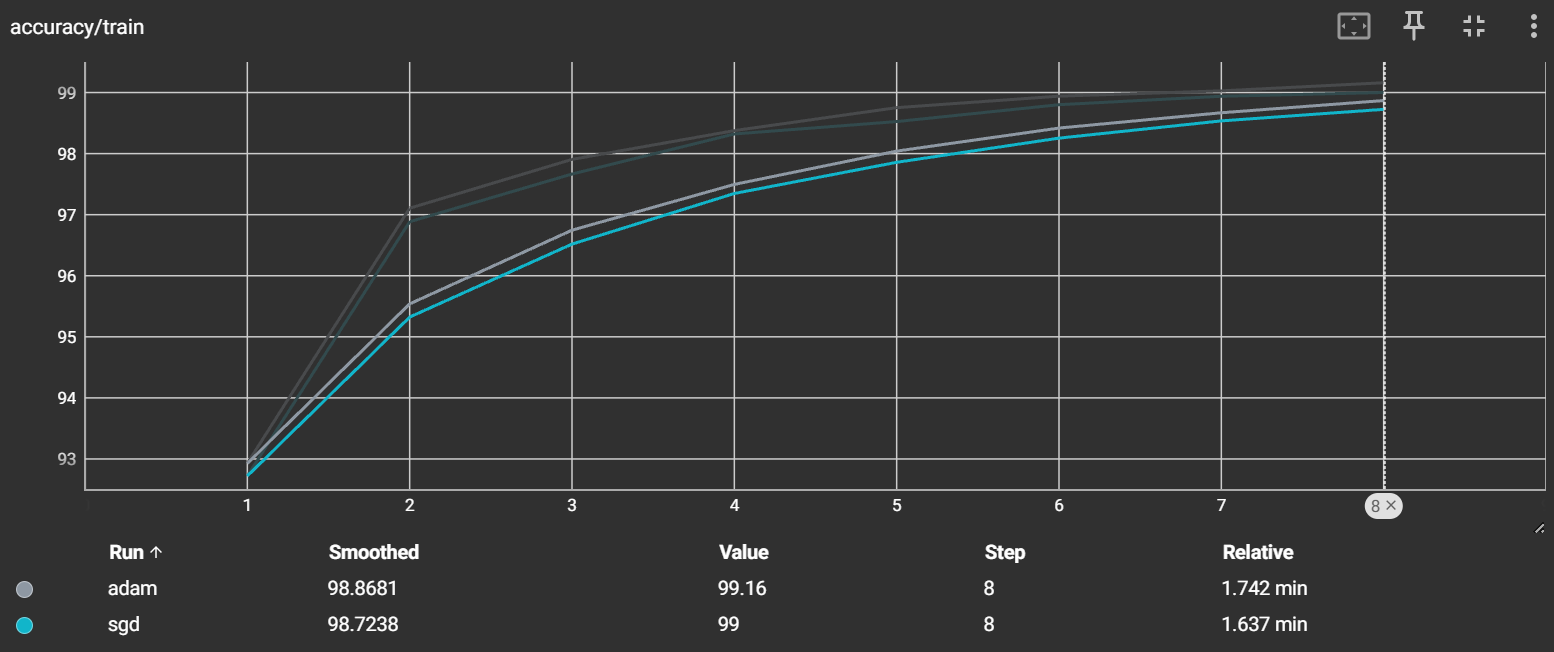
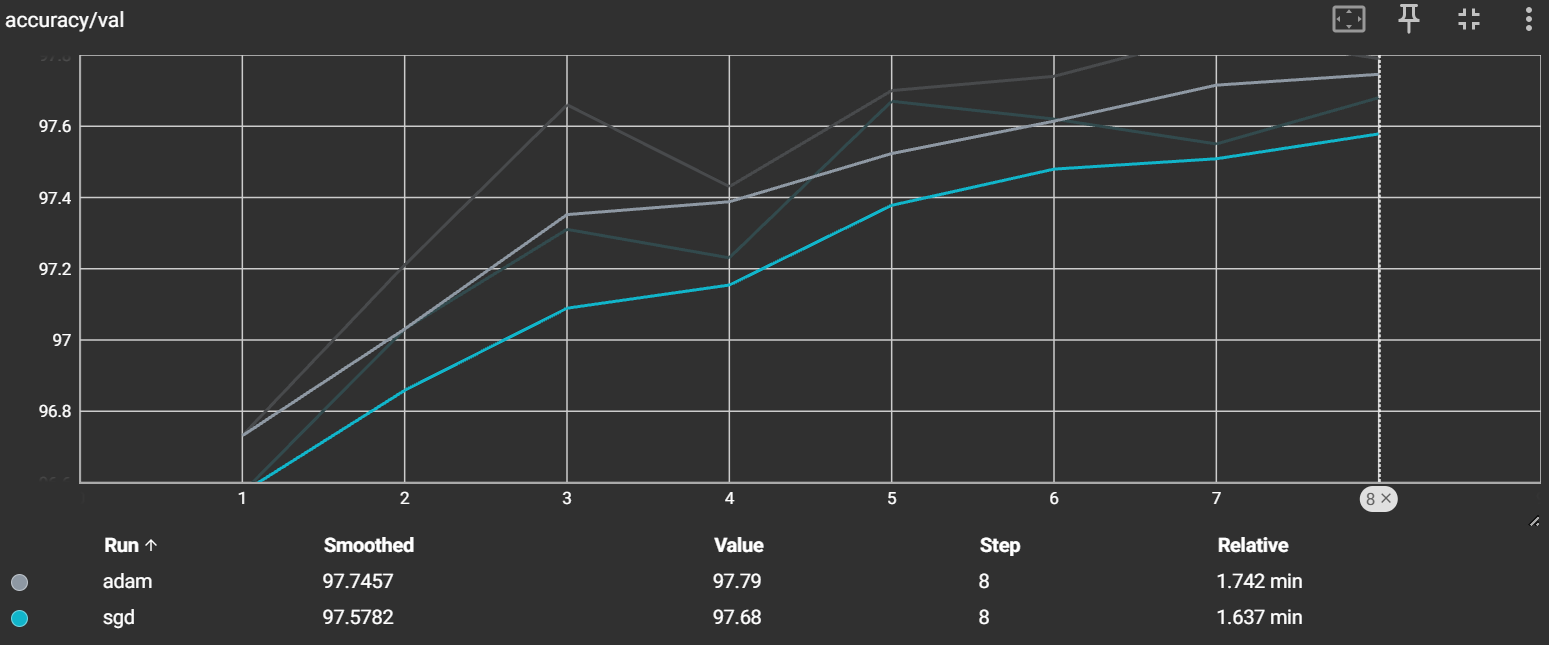
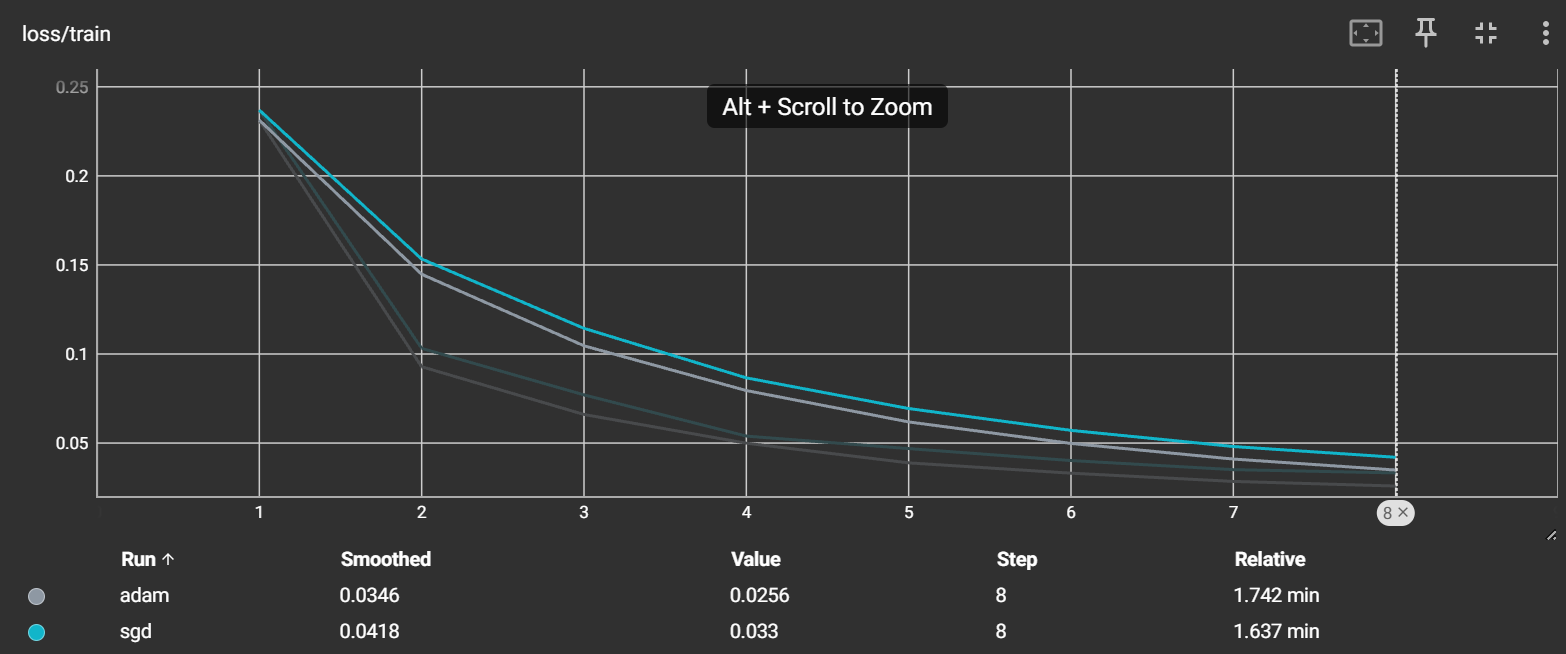
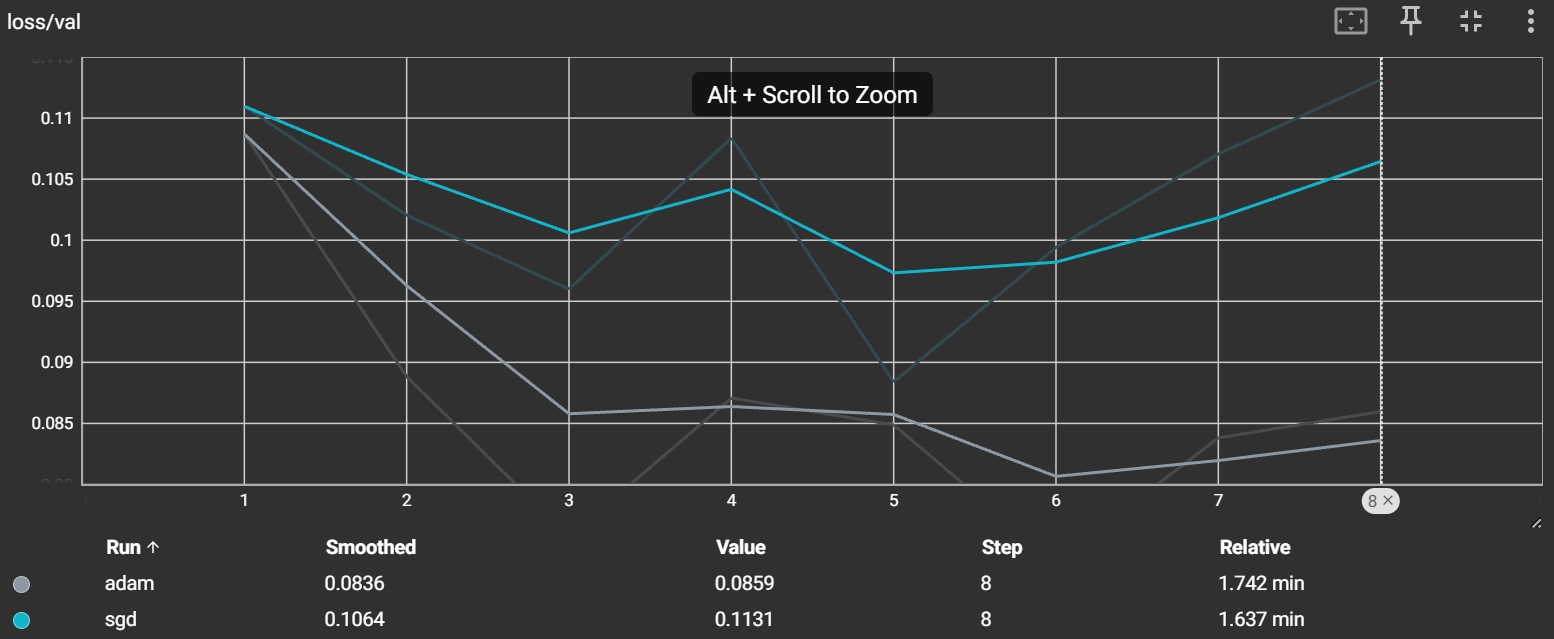


### 3. 模型迁移：
尝试将该 MLP 模型应用于 Fashion-MNIST（服装分类）数据集，观察其泛化能力； 


In [16]:
fashion_result = None
fashion_root = "./fashion_data/"

try:
    _, _, fashion_train_loader, fashion_test_loader = build_loaders(
        datasets.FashionMNIST,
        root=fashion_root,
        batch_size=64,
        mean=(0.2860,),
        std=(0.3530,),
        download=True
    )

    fashion_model = MLP(hidden_dims=[256, 128], activation="relu")
    fashion_result = train_with_history(
        model=fashion_model,
        train_loader=fashion_train_loader,
        val_loader=fashion_test_loader,
        optimizer_name="adam",
        lr=1e-3,
        epochs=8,
        patience=3,
        device=device,
        log_dir=Path("runs") / "fashion_mnist_mlp"
    )

    mnist_adam_acc = optimizer_results["Adam"]["best_val_acc"]
    print(f"\nMNIST 上使用 Adam 最佳准确率: {mnist_adam_acc:.2f}%")
    print(f"Fashion-MNIST 最佳准确率: {fashion_result['best_val_acc']:.2f}%")
    print(f"准确率差距: {mnist_adam_acc - fashion_result['best_val_acc']:.2f} %")
except Exception as e:
    print(f"Fashion-MNIST 下载或训练失败: {e}")
    print("如果当前环境没有网络访问权限，请稍后在连接的环境中运行此单元格。")


[ADAM] Epoch 01/8 | Train Loss: 0.4626, Train Acc: 83.14% | Val Loss: 0.4165, Val Acc: 84.56% | LR: 0.001000
[ADAM] Epoch 02/8 | Train Loss: 0.3468, Train Acc: 87.02% | Val Loss: 0.3844, Val Acc: 85.60% | LR: 0.001000
[ADAM] Epoch 03/8 | Train Loss: 0.3086, Train Acc: 88.53% | Val Loss: 0.3480, Val Acc: 86.90% | LR: 0.001000
[ADAM] Epoch 04/8 | Train Loss: 0.2837, Train Acc: 89.44% | Val Loss: 0.3470, Val Acc: 87.49% | LR: 0.001000
[ADAM] Epoch 05/8 | Train Loss: 0.2630, Train Acc: 90.14% | Val Loss: 0.3347, Val Acc: 87.97% | LR: 0.001000
[ADAM] Epoch 06/8 | Train Loss: 0.2474, Train Acc: 90.58% | Val Loss: 0.3458, Val Acc: 87.88% | LR: 0.001000
[ADAM] Epoch 07/8 | Train Loss: 0.2324, Train Acc: 91.11% | Val Loss: 0.3350, Val Acc: 88.58% | LR: 0.001000
[ADAM] Epoch 08/8 | Train Loss: 0.2193, Train Acc: 91.72% | Val Loss: 0.3527, Val Acc: 87.73% | LR: 0.000500

MNIST 上使用 Adam 最佳准确率: 97.86%
Fashion-MNIST 最佳准确率: 88.58%
准确率差距: 9.28 %


同样的 MLP 在 Fashion-MNIST 上表现更差，因为服装类共享更相似的形状和纹理，而扁平 MLP 无法像 CNN 那样有效地利用局部空间结构。因此，显著的准确率下降是一个合理迹象，说明任务更困难，模型在不同数据集上的泛化能力更差。
